# Evaluation of MP for modeling and DPD of a PA

In [1]:
import sys
from pathlib import Path

file_path    = str(Path.cwd())
project_path = str(Path.cwd().parent)

sys.path.append(project_path)

In [2]:
import pickle 
import torch as th
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal  import welch, firwin
from tqdm.notebook import tqdm
from tabulate      import tabulate

from optic.comm.ofdm       import modulateOFDM, demodulateOFDM
from optic.comm.modulation import modulateGray
from optic.comm.metrics    import fastBERcalc, calcEVM
from optic.dsp.core        import pnorm, finddelay, decimate, clockSamplingInterp, signal_power
from optic.dsp.coreGPU     import firFilter
from optic.utils           import parameters, dBm2W

from dpd.train          import trainNN, trainMP
from dpd.channel_models import power_amplifier
from dpd.calc_metrics   import calcACLR, calcMSE
from dpd.plots          import plotConst, plotSpec
from dpd.utils          import fitFilterNN, filterMP

In [3]:
font = {'size':16}
plt.rc('font', **font)
plt.rcParams["font.family"] = "serif"

### 1 - OFDM signal generation

In [4]:
# Parâmetros de modulação
modOrder  = 64                 # Modulation order
constType = 'qam'              # Constellation format
Rb  = 2.5e9                      # Bitrate
SpS = 4

# OFDM parameters
paramOFDM = parameters()
paramOFDM.G   = 32              
paramOFDM.SpS = SpS

paramOFDM.Nfft = 2**10
paramOFDM.nullCarriers  = np.array([paramOFDM.Nfft//2], dtype = np.int64)
paramOFDM.pilotCarriers = np.linspace(0, paramOFDM.Nfft - 1, 32, dtype = np.int64)

Nz = len(paramOFDM.nullCarriers)
Np = len(paramOFDM.pilotCarriers)
Ni = paramOFDM.Nfft - Nz - Np
numOFDMframes = 100

In [5]:
# Bits generation
np.random.seed(2)
bits = np.random.randint(2, size = (numOFDMframes*Ni, int(np.log2(modOrder))))

# Symbols modulation
symbTx = modulateGray(bits, modOrder, constType)
symbTx = pnorm(symbTx)

pilotSymb = 0.25*(max(symbTx.real) + 1j*max(symbTx.imag))
paramOFDM.pilot = pilotSymb

In [6]:
# OFDM signal generation
sigTx = modulateOFDM(symbTx, paramOFDM)

Rs = Rb / ( Ni / (paramOFDM.Nfft + paramOFDM.G) * np.log2(modOrder))
Fs = Rs * paramOFDM.SpS

t = np.arange(0, sigTx.size)*1/Fs
t_CP   = paramOFDM.SpS * paramOFDM.G * (1/Fs)
t_symb = paramOFDM.SpS * (paramOFDM.Nfft + paramOFDM.G) * (1/Fs)

In [7]:
table = [['Grandeza', 'Parâmetro', 'Valor'],
         ['Sampling rate', 'Fs', f'{Fs*1e-9:.2f} Gsamples/s'],
         ['Symbol rate', 'Rs', f'{Rs*1e-9:.2f} Gsymb/s'],
         ['Bit rate', 'Rb', f'{Rb*1e-9:.2f} GHz'],
         ['Ordem da constelação', 'M', f'{modOrder}'],
         ['Nfft', 'Nfft', f'{paramOFDM.Nfft}'],
         ['Cyclic prefix length', 'G', f'{paramOFDM.G}'],
         ['Number of information subcarriers', 'Ni', f'{Ni}'],
         ['Number of pilot subcarriers', 'Np', f'{Np}'],
         ['Number of null subcarriers', 'Nz', f'{Nz}'],
         ['Subcarriers spacing', 'Delta_f', f'{(Rs/paramOFDM.Nfft)*1e-3:.2f} kHz'],
         ['OFDM symbol period', 'T_symb', f'{1e6*t_symb:.2f} us'],
         ['Cyclic prefix duration', 'T_CP', f'{1e6*t_CP:.2f} us'] ]

print(tabulate(table, headers = 'firstrow', tablefmt = 'fancy_grid'))

╒═══════════════════════════════════╤═════════════╤═════════════════╕
│ Grandeza                          │ Parâmetro   │ Valor           │
╞═══════════════════════════════════╪═════════════╪═════════════════╡
│ Sampling rate                     │ Fs          │ 1.78 Gsamples/s │
├───────────────────────────────────┼─────────────┼─────────────────┤
│ Symbol rate                       │ Rs          │ 0.44 Gsymb/s    │
├───────────────────────────────────┼─────────────┼─────────────────┤
│ Bit rate                          │ Rb          │ 2.50 GHz        │
├───────────────────────────────────┼─────────────┼─────────────────┤
│ Ordem da constelação              │ M           │ 64              │
├───────────────────────────────────┼─────────────┼─────────────────┤
│ Nfft                              │ Nfft        │ 1024            │
├───────────────────────────────────┼─────────────┼─────────────────┤
│ Cyclic prefix length              │ G           │ 32              │
├───────────────────

### 2 - Identifying PA response (w Saleh model)

#### 2.1 Input vs Output power

In [8]:
# PA parameters
paramPA = parameters()
paramPA.model_name = "saleh"
paramPA.alpha_a   = 15.1587
paramPA.alpha_phi = 4.033
paramPA.beta_a    = 4.1517
paramPA.beta_phi  = 9.1040

In [9]:
# PA parameters
paramPA = parameters()
paramPA.model_name = "limiter"
paramPA.y_sat = 3.75
paramPA.x_sat = 0.15

In [10]:
Pin = 9

sigTx = np.sqrt(dBm2W(Pin)) * pnorm(sigTx)
sigRx = power_amplifier(sigTx, paramPA)

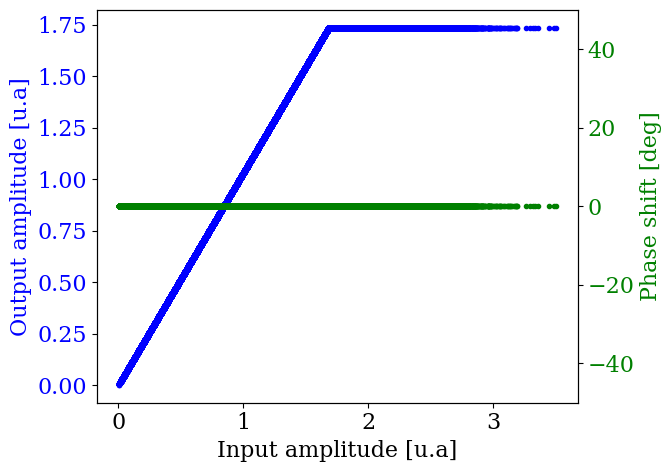

In [11]:
fig, ax1 = plt.subplots(figsize = (7, 5))
ax2 = ax1.twinx()

ax1.plot(np.abs(pnorm(sigTx)), np.abs(pnorm(sigRx)), ".", color = "b")
ax2.plot(np.abs(pnorm(sigTx)), np.unwrap(np.angle(sigRx) - np.angle(sigTx))*180/np.pi, ".", color = "g")

ax1.set_ylabel("Output amplitude [u.a]", color = "b")
ax1.set_xlabel("Input amplitude [u.a]")
ax2.set_ylabel("Phase shift [deg]", color = "g")
ax2.set_ylim(-50, 50)

ax1.tick_params(axis = 'y', labelcolor = "b")
ax2.tick_params(axis = 'y', labelcolor = "g")

plt.tight_layout()

BER = 0.00227 
EVM = 7.883 %


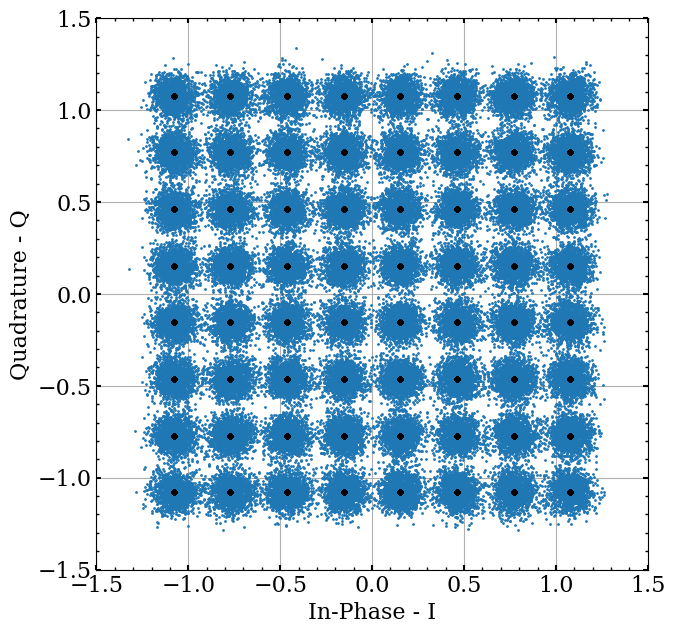

In [12]:
# Parâmetros da decimação
paramDec = parameters()
paramDec.SpS_in  = paramOFDM.SpS
paramDec.SpS_out = 1

symbRx_OFDM = decimate(sigRx, paramDec).ravel()
symbRx = demodulateOFDM(symbRx_OFDM, paramOFDM)

discard = 100
index = np.arange(discard, symbTx.size - discard)

BER, _, _ = fastBERcalc(symbRx[index], symbTx[index], modOrder, constType)
EVM = np.sqrt(calcEVM(symbRx, modOrder, constType))*100

print(f"BER = {BER[0]:.5f} \nEVM = {EVM[0]:.3f} %")

# Plot normalization
symbTx = pnorm(symbTx)
symbRx = pnorm(symbRx)

plotConst(symbTx, symbRx, axs_lim = 1.5)

SigTx - ACLR = -35.673 dB
SigRx - ACLR = -28.494 dB


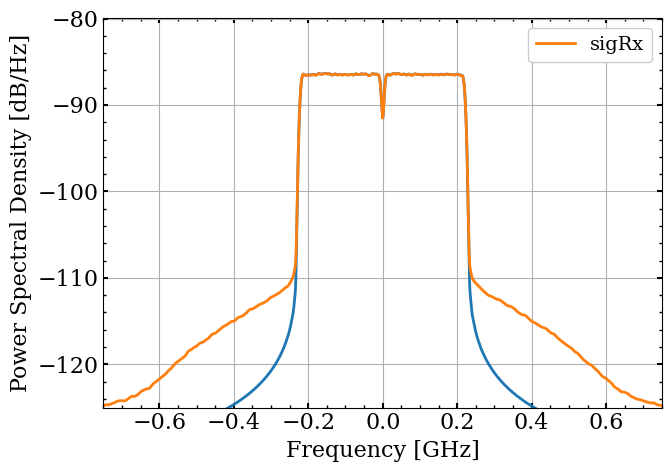

In [13]:
freq, P_sigTx = welch(pnorm(sigTx), fs = Fs, nfft = 16*1024, return_onesided = False)
freq, P_sigRx = welch(pnorm(sigRx), fs = Fs, nfft = 16*1024, return_onesided = False)

print(f"SigTx - ACLR = {calcACLR(P_sigTx, freq, Rs/2, 10e6):.3f} dB")
print(f"SigRx - ACLR = {calcACLR(P_sigRx, freq, Rs/2, 10e6):.3f} dB")

plotSpec(freq, P_sigTx, P_sigRx, label = "sigRx", x_lim = [-0.75, 0.75])

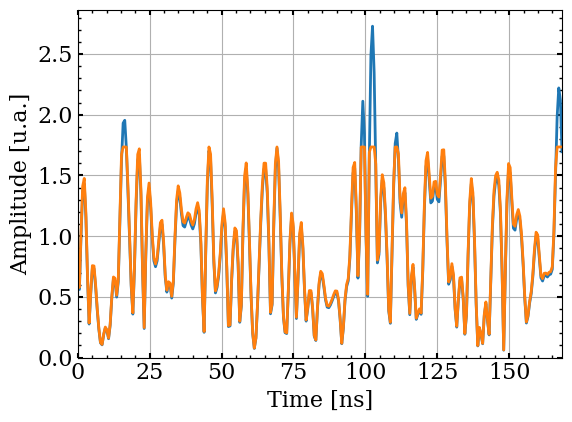

In [14]:
t = 1e9*np.arange(0, sigTx.size)*1/Fs

indx = np.arange(0, 300)

fig, axs = plt.subplots(figsize = (6, 4.5))

axs.plot(t[indx], np.abs(pnorm(sigTx)[indx]), lw = 2)
axs.plot(t[indx], np.abs(pnorm(sigRx)[indx]), lw = 2)
axs.set_xlim(np.min(t[indx]), np.max(t[indx]))
axs.set_ylim(0)

axs.set_ylabel("Amplitude [u.a.]")
axs.set_xlabel("Time [ns]")

axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs.grid()
plt.tight_layout()

### 2 - Identification and DPD with MP

In [ ]:
M = 0
P = 5

paramModel = parameters()
paramModel.model_name = "MP"
paramModel.M = M
paramModel.P = P

paramTrain = parameters()
paramTrain.epochs = 20
paramTrain.mu  = 1e-3
paramTrain.lbd = 0.9999
paramTrain.S   = np.eye(paramModel.P*(paramModel.M + 1), dtype = complex)*5e-2
paramTrain.alg = "RLS"
paramTrain.pgrsBar = True

model_ID, trainLoss_ID   = trainMP(sigTx[0:20_000], sigRx[0:20_000], paramTrain, paramModel)
model_DPD, trainLoss_DPD = trainMP(pnorm(sigRx)[0:20_000], pnorm(sigTx)[0:20_000], paramTrain, paramModel)

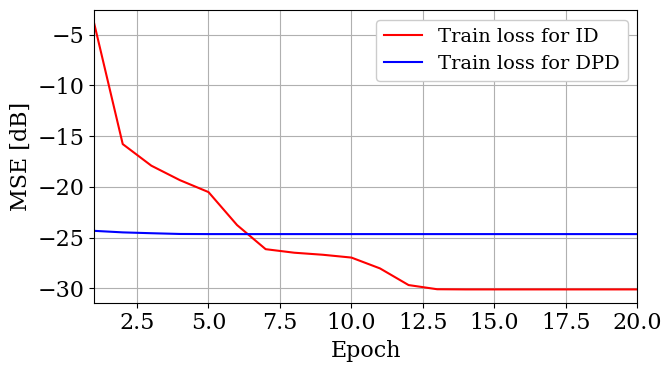

In [16]:
fig, axs = plt.subplots(figsize = (7, 4))
axs.plot(np.arange(1, paramTrain.epochs + 1), 10*np.log10(trainLoss_ID), color = "r", label = "Train loss for ID")
axs.plot(np.arange(1, paramTrain.epochs + 1), 10*np.log10(trainLoss_DPD), color = "b", label = "Train loss for DPD")

axs.set_xlim(1, paramTrain.epochs)
axs.set_ylabel("MSE [dB]")
axs.set_xlabel("Epoch")
axs.grid()
axs.legend(fontsize = 14, framealpha = 1)
plt.tight_layout()

#### 2.1 - MP for modeling

In [17]:
sigMP = filterMP(sigTx, model_ID.w.ravel(), M, P)
print(rf"MSE = {10*np.log10(calcMSE(sigMP, sigRx)):.3f} dB")

MSE = -29.441 dB


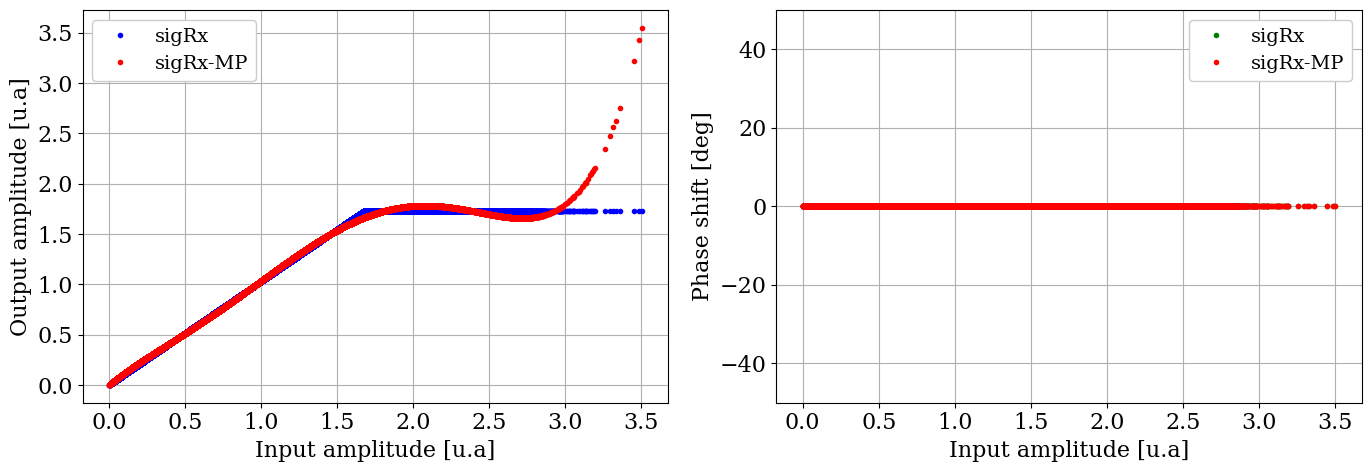

In [18]:
fig, axs = plt.subplots(1, 2, figsize = (14, 5))

axs[0].plot(np.abs(pnorm(sigTx)), np.abs(pnorm(sigRx)), ".", color = "b", label = "sigRx")
axs[0].plot(np.abs(pnorm(sigTx)), np.abs(pnorm(sigMP)), ".", color = "r", label = "sigRx-MP")

axs[1].plot(np.abs(pnorm(sigTx)), np.unwrap(np.angle(sigRx) - np.angle(sigTx))*180/np.pi, ".", color = "g", label = "sigRx")
axs[1].plot(np.abs(pnorm(sigTx)), np.unwrap(np.angle(sigMP) - np.angle(sigTx))*180/np.pi, ".", color = "r", label = "sigRx-MP")

axs[0].set_ylabel("Output amplitude [u.a]")
axs[0].set_xlabel("Input amplitude [u.a]")
axs[0].legend(fontsize = 14, framealpha = 1)
axs[0].grid()

axs[1].set_ylabel("Phase shift [deg]")
axs[1].set_xlabel("Input amplitude [u.a]")
axs[1].legend(fontsize = 14, framealpha = 1)
axs[1].set_ylim(-50, 50)
axs[1].grid()

plt.tight_layout()

#### 2.2 - MP for DPD

In [19]:
sigTx_wDPD = filterMP(pnorm(sigTx), model_DPD.w.ravel(), M, P)
gain_dpd = 10*np.log10(signal_power(sigTx_wDPD))

sigRx_wDPD = power_amplifier(np.sqrt( dBm2W(Pin + gain_dpd) ) * pnorm(sigTx_wDPD), paramPA)

print(rf"MSE = {10*np.log10(calcMSE(pnorm(sigRx_wDPD), pnorm(sigTx))):.3f} dB")

MSE = -22.622 dB


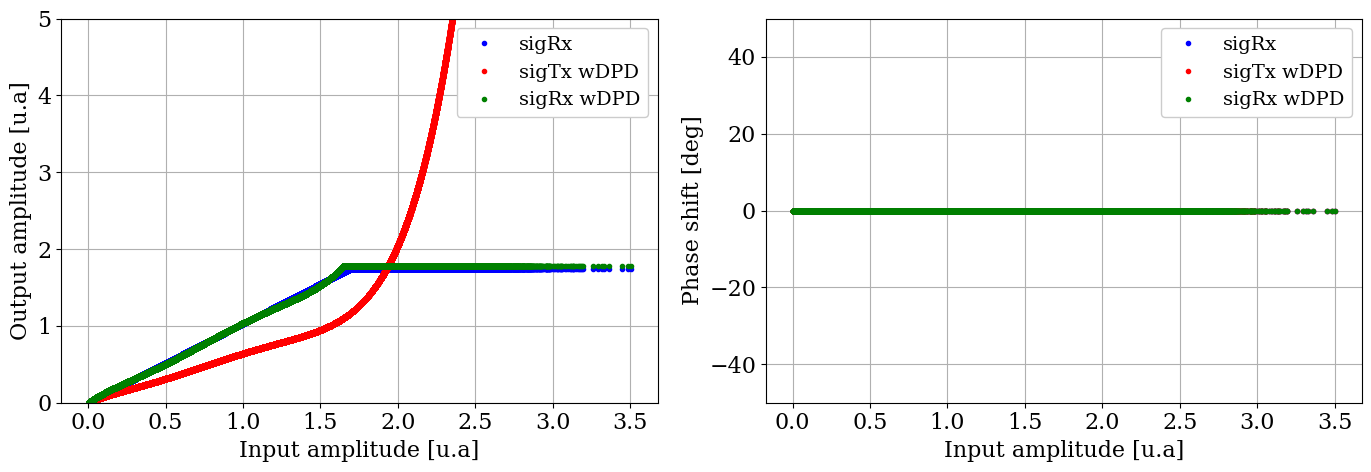

In [20]:
fig, axs = plt.subplots(1, 2, figsize = (14, 5))

axs[0].plot(np.abs(pnorm(sigTx)), np.abs(pnorm(sigRx)), ".", color = "b", label = "sigRx")
axs[0].plot(np.abs(pnorm(sigTx)), np.abs(pnorm(sigTx_wDPD)), ".", color = "r", label = "sigTx wDPD")
axs[0].plot(np.abs(pnorm(sigTx)), np.abs(pnorm(sigRx_wDPD)), ".", color = "g", label = "sigRx wDPD")

axs[1].plot(np.abs(pnorm(sigTx)), np.unwrap(np.angle(sigRx) - np.angle(sigTx))*180/np.pi, ".", color = "b", label = "sigRx")
axs[1].plot(np.abs(pnorm(sigTx)), np.unwrap(np.angle(sigTx_wDPD) - np.angle(sigTx))*180/np.pi, ".", color = "r", label = "sigTx wDPD")
axs[1].plot(np.abs(pnorm(sigTx)), np.unwrap(np.angle(sigRx_wDPD) - np.angle(sigTx))*180/np.pi, ".", color = "g", label = "sigRx wDPD")

axs[0].set_ylabel("Output amplitude [u.a]")
axs[0].set_xlabel("Input amplitude [u.a]")
axs[0].set_ylim(0, 5)
axs[0].legend(fontsize = 14, framealpha = 1)
axs[0].grid()

axs[1].set_ylabel("Phase shift [deg]")
axs[1].set_xlabel("Input amplitude [u.a]")
axs[1].legend(fontsize = 14, framealpha = 1)
axs[1].set_ylim(-50, 50)
axs[1].grid()

plt.tight_layout()

BER = 0.00122 
EVM = 7.295 %


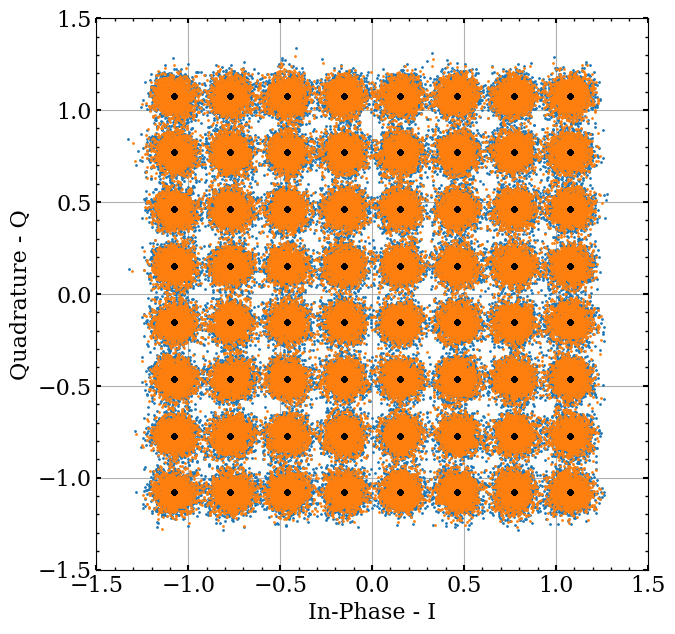

In [21]:
# Parâmetros da decimação
paramDec = parameters()
paramDec.SpS_in  = paramOFDM.SpS
paramDec.SpS_out = 1

symbRx_OFDM_wDPD = decimate(sigRx_wDPD, paramDec).ravel()
symbRx_wDPD = demodulateOFDM(symbRx_OFDM_wDPD, paramOFDM)

discard = 100
index = np.arange(discard, symbTx.size - discard)

BER, _, _ = fastBERcalc(symbRx_wDPD[index], symbTx[index], modOrder, constType)
EVM = np.sqrt(calcEVM(symbRx_wDPD, modOrder, constType))*100

print(f"BER = {BER[0]:.5f} \nEVM = {EVM[0]:.3f} %")

# Plot normalization
symbTx = pnorm(symbTx)
symbRx_wDPD = pnorm(symbRx_wDPD)

plotConst(symbTx, [symbRx, symbRx_wDPD], axs_lim = 1.5)

SigTx - ACLR = -35.673 dB
SigRx w/o DPD - ACLR = -28.494 dB
SigRx w/ DPD - ACLR = -28.914 dB


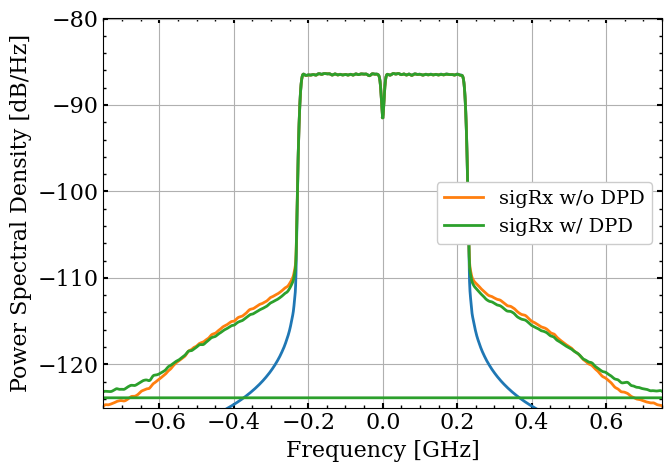

In [22]:
freq, P_sigRx_wDPD = welch(pnorm(sigRx_wDPD), fs = Fs, nfft = 16*1024, return_onesided = False)

print(f"SigTx - ACLR = {calcACLR(P_sigTx, freq, Rs/2, 10e6):.3f} dB")
print(f"SigRx w/o DPD - ACLR = {calcACLR(P_sigRx, freq, Rs/2, 10e6):.3f} dB")
print(f"SigRx w/ DPD - ACLR = {calcACLR(P_sigRx_wDPD, freq, Rs/2, 10e6):.3f} dB")

plotSpec(freq, P_sigTx, [P_sigRx, P_sigRx_wDPD], label = ["sigRx w/o DPD", "sigRx w/ DPD"], x_lim = [-0.75, 0.75])